# Chapter 121 — What is a Vector?

> **Prerequisites:** Cartesian coordinates (ch093), real numbers (ch026), functions as transformations (ch052)
> **You will learn:**
> - What distinguishes a vector from a scalar and from a list
> - The two valid ways to think about vectors: geometric and algebraic
> - Why vectors are the fundamental unit of computation in data science and ML
> - How to construct and inspect vectors in NumPy

> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **scalar** is a single number: temperature, mass, price.

A **vector** is a quantity with both **magnitude** (how much) and **direction** (which way). Wind velocity is a vector: 30 km/h is not enough information — 30 km/h *northeast* is.

This sounds like a geometric concept, and it is. But vectors also have an algebraic face: a vector can be written as an ordered list of numbers — its **components** with respect to a coordinate system. The 2D vector pointing northeast with speed 30 might be `[21.2, 21.2]` in Cartesian coordinates.

The critical point: **the list is a representation, not the thing itself.** Change the coordinate system and the list changes, but the vector — the arrow — stays the same.

**Common misconceptions:**
- A vector is not just a list. A list is a data structure. A vector is a mathematical object with defined operations.
- A 1D vector is not a scalar. It is a vector that happens to live in a 1-dimensional space.
- The zero vector `[0, 0]` is a valid vector with magnitude 0 and undefined direction.

---

## 2. Intuition & Mental Models

**Geometric model:** Think of a vector as an arrow anchored at the origin. Its length is its magnitude. The direction it points is its direction. Two vectors are equal if and only if they have the same length and point the same direction — regardless of where they are drawn.

**Computational model:** Think of a vector as a fixed-length array of numbers with two operations defined: component-wise addition, and scaling by a constant. Everything else (dot products, norms, projections) is derived from these two.

**Physical model:** Force is a vector. Displacement is a vector. Velocity is a vector. In physics, scalars are quantities that don't depend on direction (mass, energy). Vectors are quantities that do.

Recall from ch093 (Cartesian Coordinates) that points in the plane are specified by pairs `(x, y)`. A vector from the origin to point `(x, y)` is the arrow connecting those two points. The connection between points and vectors is direct.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_19844\2686490871.py:31: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_19844\2686490871.py:31: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_19844\2686490871.py:31: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarn

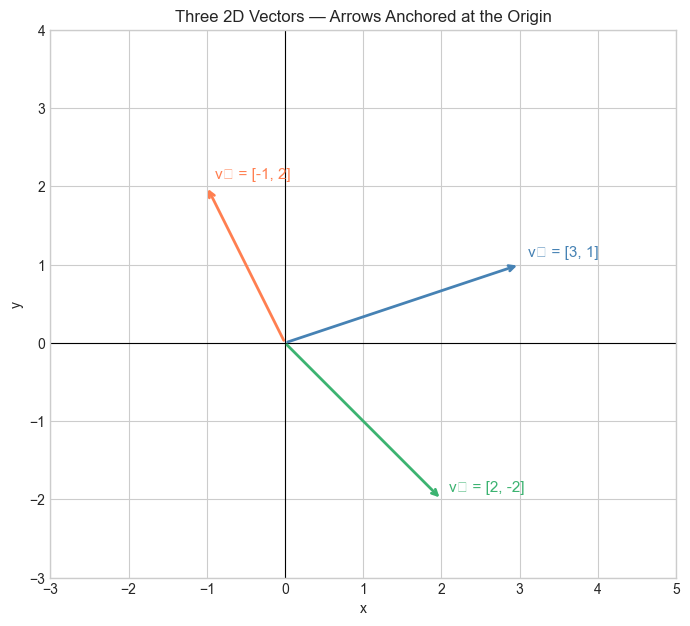

In [1]:
# --- Visualization: Vectors as arrows in 2D ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Define three vectors
vectors = {
    'v₁ = [3, 1]':  (3,  1,  'steelblue'),
    'v₂ = [-1, 2]': (-1, 2,  'coral'),
    'v₃ = [2, -2]': (2,  -2, 'mediumseagreen'),
}

fig, ax = plt.subplots(figsize=(7, 7))

ORIGIN = np.array([0, 0])
for label, (x, y, color) in vectors.items():
    ax.annotate(
        '', xy=(x, y), xytext=ORIGIN,
        arrowprops=dict(arrowstyle='->', color=color, lw=2)
    )
    ax.text(x + 0.1, y + 0.1, label, color=color, fontsize=11)

ax.set_xlim(-3, 5)
ax.set_ylim(-3, 4)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Three 2D Vectors — Arrows Anchored at the Origin')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Each arrow starts at the origin. Its tip is at the coordinates given by its components. The length and direction are the two things that define it.

---

## 4. Mathematical Formulation

A vector **v** in ℝⁿ is an ordered n-tuple of real numbers:

$$\mathbf{v} = \begin{pmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{pmatrix}$$

Where:
- $v_i$ is the $i$-th component of **v**
- ℝⁿ is the set of all n-dimensional real vectors
- The **dimension** of the vector is $n$

Two vectors **u** and **v** in ℝⁿ are **equal** if and only if $u_i = v_i$ for all $i = 1, \ldots, n$.

The **zero vector** is $\mathbf{0} = (0, 0, \ldots, 0)$.

Notation:
- Bold lowercase: **v** — a vector
- Regular lowercase: $v_i$ — a scalar component
- Regular uppercase: $V$ — often a matrix or set (Part VI)

In [2]:
# --- Mathematical Formulation: Vectors in NumPy ---
import numpy as np

# A 2D vector
v1 = np.array([3.0, 1.0])   # shape: (2,)

# A 3D vector
v2 = np.array([1.0, -2.0, 4.0])  # shape: (3,)

# A 5D vector (same math, just can't draw it)
v3 = np.array([0.1, 0.5, 0.2, 0.8, 0.4])  # shape: (5,)

print("v1:", v1, "  shape:", v1.shape, "  dtype:", v1.dtype)
print("v2:", v2, "  shape:", v2.shape)
print("v3:", v3, "  shape:", v3.shape)

# Accessing components
print("\nFirst component of v2:", v2[0])
print("All components of v3:", [v3[i] for i in range(len(v3))])

# The zero vector
zero_3d = np.zeros(3)
print("\nZero vector (3D):", zero_3d)

v1: [3. 1.]   shape: (2,)   dtype: float64
v2: [ 1. -2.  4.]   shape: (3,)
v3: [0.1 0.5 0.2 0.8 0.4]   shape: (5,)

First component of v2: 1.0
All components of v3: [np.float64(0.1), np.float64(0.5), np.float64(0.2), np.float64(0.8), np.float64(0.4)]

Zero vector (3D): [0. 0. 0.]


## 5. Python Implementation

In [3]:
# --- Implementation: Vector class from scratch ---
# We build a minimal vector type to make the operations explicit.
# In practice we use NumPy, but this clarifies what a vector *is*.

class Vector:
    """
    A simple n-dimensional vector.

    Args:
        components: list or tuple of real numbers
    """

    def __init__(self, components):
        self.data = list(float(c) for c in components)
        self.dim = len(self.data)

    def __repr__(self):
        formatted = ', '.join(f'{c:.3g}' for c in self.data)
        return f'Vector([{formatted}])'

    def __len__(self):
        return self.dim

    def __getitem__(self, i):
        return self.data[i]

    def __eq__(self, other):
        """Two vectors are equal iff all components are equal."""
        if self.dim != other.dim:
            return False
        return all(abs(a - b) < 1e-10 for a, b in zip(self.data, other.data))


# Test it
v = Vector([3, 1, -2])
w = Vector([3, 1, -2])
u = Vector([1, 0,  2])

print("v:", v)
print("w:", w)
print("u:", u)
print("v == w:", v == w)   # True
print("v == u:", v == u)   # False
print("dim of v:", len(v))
print("Second component:", v[1])

v: Vector([3, 1, -2])
w: Vector([3, 1, -2])
u: Vector([1, 0, 2])
v == w: True
v == u: False
dim of v: 3
Second component: 1.0


## 6. Experiments

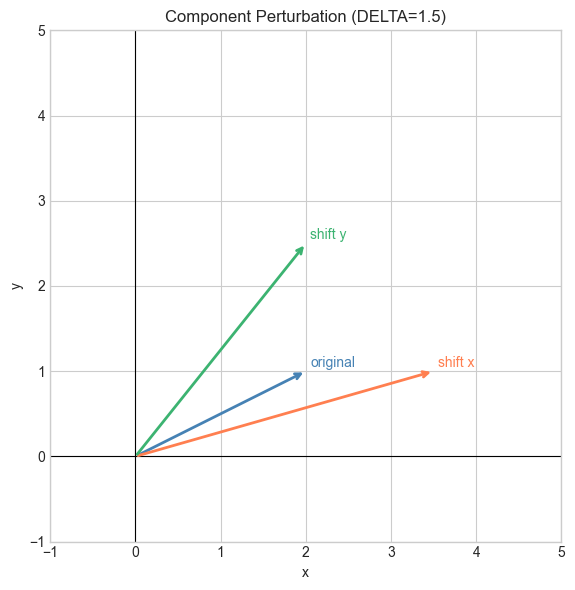

In [4]:
# --- Experiment 1: What changes a vector? ---
# Hypothesis: changing any single component produces a different vector.
# Try changing: which component you modify, and by how much.
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

original = np.array([2.0, 1.0])
DELTA = 1.5   # <-- modify this

variant_x = original + np.array([DELTA, 0])   # shift x component
variant_y = original + np.array([0, DELTA])   # shift y component

fig, ax = plt.subplots(figsize=(6, 6))
for vec, label, color in [
    (original,  'original', 'steelblue'),
    (variant_x, 'shift x',  'coral'),
    (variant_y, 'shift y',  'mediumseagreen'),
]:
    ax.annotate('', xy=vec, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(vec[0]+0.05, vec[1]+0.05, label, color=color)

ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.axhline(0, color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8)
ax.set_aspect('equal')
ax.set_title(f'Component Perturbation (DELTA={DELTA})')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [5]:
# --- Experiment 2: High-dimensional vectors ---
# Hypothesis: NumPy handles 1000-dimensional vectors as easily as 2D.
# Try changing: N to 1, 10, 100, 10000
import numpy as np

N = 1000   # <-- modify this

v = np.random.randn(N)
print(f"Vector dimension: {N}")
print(f"First 5 components: {v[:5]}")
print(f"Shape: {v.shape}")
print(f"Memory usage: {v.nbytes} bytes")

Vector dimension: 1000
First 5 components: [-0.23124872 -0.78658485 -2.29913912  0.37080701  0.10530274]
Shape: (1000,)
Memory usage: 8000 bytes


## 7. Exercises

**Easy 1.** Create a 4D vector **v** = (1, −3, 0, 7) using NumPy. Print its shape, dimension, and third component. *(Expected: shape (4,), dim 4, third component 0)*

**Easy 2.** Are the vectors (2, 3) and (3, 2) equal? Why or why not? *(Expected: no — order matters in vectors)*

**Medium 1.** Write a function `are_equal(u, v, tol=1e-9)` that returns `True` if two NumPy vectors are equal component-wise within tolerance `tol`. Test it on (1.0, 2.0) vs (1.0, 2.0 + 1e-11).

**Medium 2.** Create a random 100-dimensional vector with `np.random.randn(100)`. What percentage of components are negative? Does this match what you'd expect? Run it 10 times and report the range.

**Hard.** The standard basis vectors in ℝ³ are **e₁** = (1,0,0), **e₂** = (0,1,0), **e₃** = (0,0,1). Show computationally that any vector **v** = (a, b, c) can be written as $a\mathbf{e_1} + b\mathbf{e_2} + c\mathbf{e_3}$. What does this suggest about the relationship between coordinates and basis vectors? *(Challenge: this generalizes to ch139 — Basis and Dimension)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Wind Vector Display ---
# Problem: A weather station records wind readings as (speed_kmh, direction_degrees)
#          Convert each reading to a Cartesian vector and display on a map grid.
# Dataset: generated sensor readings
# Task: implement polar_to_cartesian(), display arrows on a grid

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Sensor grid positions (x, y in km)
grid_x = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2], dtype=float)
grid_y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2], dtype=float)

# Wind readings: (speed km/h, direction degrees clockwise from North)
readings = np.array([
    [15, 45], [20, 90], [18, 135],
    [12, 30], [25, 60], [22, 90],
    [10, 0],  [16, 80], [19, 110],
])

def polar_to_cartesian(speed, direction_deg):
    """
    Convert polar wind reading to Cartesian vector.

    Args:
        speed: wind speed (km/h)
        direction_deg: direction in degrees, clockwise from North

    Returns:
        (vx, vy): Cartesian components
    """
    # TODO: implement this
    # Hint: North is +y. East is +x.
    # A 0-degree wind blows North (positive y).
    # A 90-degree wind blows East (positive x).
    # Use np.deg2rad(), np.cos(), np.sin()
    pass

# --- When complete, this should display a wind field ---
# vx = np.array([polar_to_cartesian(s, d)[0] for s, d in readings])
# vy = np.array([polar_to_cartesian(s, d)[1] for s, d in readings])
#
# fig, ax = plt.subplots(figsize=(7, 7))
# ax.quiver(grid_x, grid_y, vx, vy, scale=200, color='steelblue')
# ax.set_title('Wind Field — Vector Representation')
# ax.set_xlabel('km East'); ax.set_ylabel('km North')
# plt.tight_layout(); plt.show()

## 9. Summary & Connections

- A vector is a quantity with magnitude and direction, represented as an ordered tuple of real numbers.
- The list representation depends on the coordinate system; the vector itself does not.
- In ℝⁿ, two vectors are equal iff all n components are equal.
- NumPy `ndarray` with shape `(n,)` is the standard vector representation in Python.

**Backward connection:** This formalizes the coordinate pairs from ch093 (Cartesian Coordinates). A point `(x, y)` and a vector `[x, y]` from the origin are the same object viewed differently.

**Forward connections:**
- This will reappear in ch125 — Vector Addition, where the arrow model makes addition geometric and intuitive.
- This will reappear in ch137 — Vector Spaces, where we ask what abstract properties a set of objects must have to be called 'vectors'.
- This will reappear in ch145 — Vectors in Machine Learning, where a datapoint with n features is exactly a vector in ℝⁿ.